# PT-13 — Les trois biais du loss GRPO et leurs corrections 2025 (Dr. GRPO, DAPO)

[← PostTraining](../README.md) · série from-scratch (torch CPU, sans `trl`) · suite directe de PT-08/PT-09/PT-10/PT-12

GRPO (DeepSeekMath, 2024) a permis R1-Zero, mais son *objectif* porte trois termes de normalisation
dont deux papiers de 2025 montrent qu'ils induisent des biais :

- **Dr. GRPO** (Liu et al., fév. 2025, *Understanding R1-Zero-Like Training*) : deux corrections au loss
  (le `÷|o_i|` et le `÷std`).
- **DAPO** (Yu et al., mars 2025, Qwen) : trois corrections au niveau du *pipeline* (clip-higher,
  dynamic sampling, loss token-level). Seul *clip-higher* touche le loss lui-même.

Ce notebook **n'entraîne pas de LLM** (PT-11x le fait) : il mesure, cellule par cellule, ce que chacune
des trois normalisations **change au gradient**, sur un `toy env` CPU dans la lignée PT-08…PT-12.
Le verdict est en forme `MECANISME_REPRO` (le biais est reproduit) ou `NON_REPRO` (le banc ne le montre pas)
— jamais `BEATS`.

## Contexte : où vivent les trois biais

L'objectif GRPO standard (une réponse `o_i` par échantillon d'un groupe de `G`) s'écrit

$$ L^{GRPO} = -\frac{1}{G}\sum_i \frac{1}{|o_i|}\sum_{t} \min\!\left(\rho_{i,t}\hat A_i,\ \text{clip}(\rho_{i,t},1-\varepsilon,1+\varepsilon)\hat A_i\right) + \beta\ KL $$

avec `ρ_{i,t} = π_θ(o_{i,t})/π_{θ_old}(o_{i,t})` et l'avantage de groupe $\hat A_i = (r_i-\mu)/\sigma$.

Trois termes y sont discutés en 2025 :

| Terme | Rôle | Biais identifié | Correction |
|---|---|---|---|
| `1/|o_i|` | normalise par la longueur de la réponse | **biais de récompense en fonction de la longueur** : une réponse *longue erronée* voit sa pénalité diluée (la valeur de la pénalité totale ne dépend plus de la longueur) | Dr. GRPO : remplacer `1/|o_i|` par une constante `1/|o_max|` |
| `(r_i-μ)/σ` | normalise l'avantage par la dispersion du groupe | **biais de difficulté** : un groupe *quasi uniforme* (7 corrects sur 8) voit son unique erreur amplifiée autant qu'un groupe vraiment mitigé | Dr. GRPO : retirer `÷σ`, garder `r_i-μ` |
| `clip(ρ,1-ε,1+ε)` | borne le ratio de politique | **effondrement d'entropie** : un token *rare* qu'on veut remonter est immédiatement clipé à `1+ε`, son gradient s'annule | DAPO : **clip-higher** `ε_high > ε_low` (`0.28 > 0.2`) |

Ce notebook isole chaque terme et mesure son effet. La partie 1 pose le banc (toy env + politique + les
trois variantes de loss). La partie 2 mesure les biais exactement (arithmétique du loss). La partie 3
entraîne réellement et rapporte ce que le banc *montre* — y compris la limite honnête où il ne montre rien.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import z3

torch.set_num_threads(4)
np.set_printoptions(precision=3, suppress=True)
print("torch", torch.__version__, "| numpy", np.__version__, "| z3", z3.get_version_string())

torch 2.6.0+cu124 | numpy 2.4.6 | z3 5.0.0


## Partie 1 — Le banc toy

### 1.1 Environnement : une réponse à position libre, du *padding* permis

Vocabulaire `{P=0, B0=1, B1=2, S=3}`. Un prompt est une clé `c ∈ {0,1}` ; la réponse correcte est
`[B_c, S]` (le bit attendu puis STOP). Le **padding** `P` peut être inséré avant : `[P, P, B_c, S]`
reste correct — le vérificateur ne regarde que le token juste avant `S`.

Ce banc rend la *longueur* saillante : une réponse peut être correcte-courte, correcte-longue,
erronée-courte ou erronée-longue. C'est exactement la dimension où `1/|o_i|` travaille.

In [2]:
T_MAX = 8          # longueur maximale de génération
VOCAB = 4          # 0=P, 1=B0, 2=B1, 3=S
ANS_LEN = 1        # bits de réponse avant STOP
G = 8              # taille de groupe GRPO
KEYMAP = {0: 1, 1: 2}   # clé -> token de réponse correct

def target_tokens(key):
    return [KEYMAP[key]]

def verify_fastpath(seqs, keys):
    """seqs: [B,T] int (tri -1 = hors séquence), keys: [B] int. Reward binaire."""
    B = seqs.shape[0]
    out = np.zeros(B, dtype=np.float32)
    for i in range(B):
        L = int((seqs[i] >= 0).sum())
        if L >= ANS_LEN + 1 and seqs[i, L - 1].item() == 3:
            ans = [seqs[i, L - 1 - ANS_LEN + t].item() for t in range(ANS_LEN)]
            out[i] = 1.0 if ans == target_tokens(keys[i].item()) else 0.0
    return out

# quelques cas pour fixer la sémantique
demo = torch.tensor([[1, 3, -1, -1, -1, -1, -1, -1],
                     [0, 0, 1, 3, -1, -1, -1, -1],
                     [2, 3, -1, -1, -1, -1, -1, -1]])
print("rewards (c=0):", verify_fastpath(demo, torch.tensor([0, 0, 0])))

rewards (c=0): [1. 1. 0.]


**Lecture (design de l'environnement).** La démo fixe la sémantique sur trois cas contrastés :
`[B0, S]` reçoit 1, `[P, P, B0, S]` reçoit aussi 1, `[B1, S]` reçoit 0 — la reward imprimée
`[1. 1. 0.]` dit exactement cela. Deux propriétés font de ce petit monde un banc valable pour le
biais de longueur : (i) la **reward ne dépend pas de la longueur** — le vérificateur ne regarde que
le token juste avant `S`, donc allonger par du padding ne change rien à la note ; (ii) les **quatre
situations coexistent** — correct-court, correct-long, erroné-court, erroné-long — ce sont les
buckets que la partie 2 mesurera un à un. Si la reward ignorait la longueur *et* que toutes les
réponses avaient la même longueur, le terme `1/|o_i|` n'aurait aucune prise ; c'est en rendant la
longueur libre (et gratuite) qu'on lui donne prise. Les constantes en tête de cellule paramètrent
le compromis : `T_MAX = 8` borne la longueur maximale (un padding infini n'apprendrait rien de
plus), `G = 8` fixe la taille de groupe dont la moyenne servira de baseline, `ANS_LEN = 1` garde
la tâche à un bit pour que la mécanique du loss — et non la difficulté du problème — reste
l'unique variable.

### 1.2 Le vérificateur Z3 (thème RLVR, continuité PT-11x/PT-12)

RLVR utilise un vérificateur *exact*. Ici la récompense est triviale ; on la porte en Z3 pour
rappeler le thème et vérifier l'équivalence fast-path/Z3 (comme PT-12).

In [3]:
def verify_z3(tokens, key):
    """Vérifieur exact (thème RLVR) : la trajectoire observée satisfait-elle le spec du trailer ?
    spec = le token juste avant STOP est le bit attendu pour `key`. Z3 prouve la contrainte."""
    stop = len(tokens) - 1
    sol = z3.Solver()
    s = z3.Int("s")
    sol.add(s == stop)                    # la position STOP observée (le dernier token émis)
    sol.add(s >= ANS_LEN, s < T_MAX)
    sol.add(tokens[stop] == 3)            # le dernier token EST un STOP
    tgt = target_tokens(key)
    sol.add(z3.And([tokens[stop - 1 - i] == tgt[i] for i in range(ANS_LEN)]))
    return sol.check()

def verify_z3_tensor(seqs, keys):
    """[B,T] (tri -1) -> bool par ligne : verifie par Z3 (decoupe au premier STOP)."""
    out = []
    for i in range(seqs.shape[0]):
        toks = [t.item() for t in seqs[i] if t >= 0]
        out.append(verify_z3(toks, keys[i].item()) == z3.sat)
    return out

# test : deux sequences (une correcte c=0, une erronée)
t_corr = [1, 3]; t_wrong = [2, 3]
print("Z3 correct (c=0) :", verify_z3(t_corr, 0), "| Z3 wrong (c=0):", verify_z3(t_wrong, 0))

Z3 correct (c=0) : sat | Z3 wrong (c=0): unsat


**Lecture (le vérificateur rend sat/unsat).** Les deux sorties (`sat` pour la séquence correcte,
`unsat` pour l'erronée) rappellent ce qu'est RLVR : la reward n'est pas une heuristique notée,
c'est la **satisfaisabilité d'une contrainte** — la séquence encodée satisfait la spécification
« le bit juste avant `S` égale le bit de la clé » ou ne la satisfait pas, sans zone grise. Le
notebook maintient deux chemins vers cette décision : la `fastpath` Python (utilisée à chaque
itération d'entraînement, pour la vitesse) et la formulation Z3 (la référence symbolique, thème
filé depuis PT-11x/PT-12). Toute la valeur de la double écriture tient dans l'équivalence entre
les deux — elle est re-vérifiée en fin de notebook sur des séquences fraîches, et c'est ce qui
autorise à dire que la politique a bien été entraînée contre le vérificateur exact, pas contre
une approximation de celui-ci.

### 1.3 La politique : MLP pur acteur (famille no-critic, PT-08)

GRPO n'a pas de *critic* (c'est sa raison d'être vs PPO) — la politique est seule. Entrée :
one-hot de la clé (2), one-hot de la position (T_MAX), one-hot du dernier token (4).

In [4]:
class PolicyMLP(nn.Module):
    """Pur acteur autonome, sans valeur ni critic."""
    def __init__(self, hid=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 + T_MAX + VOCAB, hid), nn.Tanh(),
            nn.Linear(hid, hid), nn.Tanh(),
            nn.Linear(hid, VOCAB))
        nn.init.zeros_(self.net[-1].bias)   # sortie neutre au départ

    def forward(self, keys, pos, last):
        k = nn.functional.one_hot(keys, 2).float()
        pe = torch.zeros(len(keys), T_MAX)
        pe[torch.arange(len(keys)), pos] = 1.0
        l = nn.functional.one_hot(last, VOCAB).float()
        return self.net(torch.cat([k, pe, l], 1))

def token_logprobs(model, keys, seqs, lens):
    """[B, T] log-probs des tokens réels (0 hors séquence)."""
    B = len(keys)
    lp = torch.zeros(B, T_MAX)
    last = torch.zeros(B, dtype=torch.long)
    for t in range(T_MAX):
        act = seqs[:, t]
        do = act >= 0
        if do.any():
            idx = do.nonzero(as_tuple=True)[0]
            logits = model(keys[idx], torch.full((len(idx),), t, dtype=torch.long), last[idx])
            lp[idx, t] = torch.distributions.Categorical(logits=logits).log_prob(act[idx])
        last = torch.where(do, act.clamp(min=0), last)
    return lp

print("PolicyMLP (params):", sum(p.numel() for p in PolicyMLP().parameters()))

PolicyMLP (params): 5380


**Lecture (un acteur seul, qui sait où il en est).** L'entrée du MLP concatène trois one-hot :
la clé (le prompt), la position courante, le dernier token émis — assez pour que la politique
reconstitue l'état de sa génération sans mémoire récurrente, donc assez pour que tout ce qui se
joue ensuite soit attribuable au **loss**, pas à une architecture qui compenserait. La sortie est
une distribution sur les quatre tokens du vocabulaire ; `token_logprobs` renvoie, pour chaque
séquence, le log-probabilité de chaque token *réellement* émis (0 hors séquence) — c'est la
quantité que le loss déplacera. Deux choix d'initialisation méritent l'œil : le biais de sortie
est mis à zéro (politique neutre au départ), et `p_bias` sera posé à 1 au début de la partie 2
pour rendre le token de padding attractif — sans cela, des trajectoires initiales sans aucun
padding ne laisseraient jamais au biais de longueur l'occasion de s'exercer. La cellule suivante
échantillonne `G` réponses par clé : c'est ce groupe qui fournit à la fois la baseline
(la moyenne) et l'écart-type dont le `÷σ` sera accusé.

In [5]:
def rollout(model, keys, G, greedy=False):
    """Génère G réponses par prompt. keys [P] -> seqs [P*G, T], lens [P*G]."""
    P = len(keys)
    keys_r = keys.repeat_interleave(G)
    B = P * G
    seqs = torch.full((B, T_MAX), -1, dtype=torch.long)
    lens = torch.zeros(B, dtype=torch.long)
    alive = torch.ones(B, dtype=torch.bool)
    last = torch.zeros(B, dtype=torch.long)
    for t in range(T_MAX):
        idx = alive.nonzero(as_tuple=True)[0]
        if len(idx) == 0:
            break
        with torch.no_grad():
            logits = model(keys_r[idx], torch.full((len(idx),), t, dtype=torch.long), last[idx])
            a = logits.argmax(-1) if greedy else torch.distributions.Categorical(logits=logits).sample()
        seqs[idx, t] = a
        now_dead = idx[a == 3]
        lens[idx] = t + 1
        alive[now_dead] = False
        last[idx] = a
    return keys_r, seqs, lens

# appel témoin (politique neutre) : taux de succès aléatoire attendu ~ (1/2)^ANS_LEN * P(STOP)
torch.manual_seed(0)
m = PolicyMLP()
kr, ss, ll = rollout(m, torch.tensor([0, 1]), 4)
print("lens:", ll.tolist())
print("succ brut (c=0,1):", verify_fastpath(ss, kr).mean().item())

lens: [2, 1, 2, 3, 7, 4, 7, 5]
succ brut (c=0,1): 0.25


### 1.4 Les trois variantes de loss — une fonction, trois configurations

Le degré de liberté du notebook est exactement le couple `(normalisation, bornes de clip)`. Une seule
fonction `grpo_loss` rend les trois variantes : `vanilla` (le GRPO d'origine), `dr` (Dr. GRPO), et
`clip_higher` (le GRPO d'origine + la borne haute élargie de DAPO). Cette factorisation *est* l'argument :
les corrections sont des retraits/réglages de termes qui se touchent à la main.

In [6]:
def make_advantage(rewards, std_norm):
    a = rewards - rewards.mean(1, keepdim=True)
    if std_norm:
        a = a / (rewards.std(1, keepdim=True) + 1e-4)
    return a

def make_loss(norm="len", std_norm=True, eps_lo=0.2, eps_hi=0.2):
    """norm: 'len' (1/|o_i|, vanilla) ou 'const' (1/T_MAX, Dr. GRPO)."""
    def loss(model, keys, seqs, lens, adv, lp_old):
        lp = token_logprobs(model, keys, seqs, lens)
        mask = (torch.arange(T_MAX).unsqueeze(0) < lens.unsqueeze(1)).float()
        ratio = torch.exp(lp - lp_old)
        un = ratio * adv.unsqueeze(1)
        cl = torch.clamp(ratio, 1 - eps_lo, 1 + eps_hi) * adv.unsqueeze(1)
        per_tok = -torch.min(un, cl) * mask
        denom = lens.float() if norm == "len" else torch.full_like(lens.float(), float(T_MAX))
        return (per_tok.sum(1) / denom).mean(), per_tok
    return loss

def make_cfg(variant):
    cfg = dict(norm="len", std_norm=True, eps_lo=0.2, eps_hi=0.2)
    if variant == "dr":
        cfg.update(norm="const", std_norm=False)          # Dr. GRPO : const + pas de /std
    elif variant == "clip_higher":
        cfg.update(eps_hi=0.28)                           # DAPO : borne haute élargie
    return cfg

print("variantes :", [make_cfg(v) for v in ["vanilla", "dr", "clip_higher"]])

variantes : [{'norm': 'len', 'std_norm': True, 'eps_lo': 0.2, 'eps_hi': 0.2}, {'norm': 'const', 'std_norm': False, 'eps_lo': 0.2, 'eps_hi': 0.2}, {'norm': 'len', 'std_norm': True, 'eps_lo': 0.2, 'eps_hi': 0.28}]


**Lecture (trois corrections, trois différences d'une ligne).** L'intérêt de la factorisation
est de rendre les corrections *visibles comme des deltas* :

$$\mathcal{L}_{\text{vanilla}} = \mathbb{E}\left[\frac{1}{|o_i|}\sum_t \min\!\big(r_t \hat{A}_i,\ \mathrm{clip}(r_t, 1-\varepsilon, 1+\varepsilon)\, \hat{A}_i\big)\right], \qquad \hat{A}_i = \frac{r_i - \mu_{\text{groupe}}}{\sigma_{\text{groupe}} + 10^{-4}}$$

- `dr` remplace le dénominateur `1/|o_i|` par `1/T_MAX` (`norm="const"`) : le facteur de
  longueur devient identique pour toutes les réponses, donc s'annule de la comparaison — c'est le
  retrait du **bouclier de longueur** décrit par Liu et al. (2025) ;
- `dr` pose aussi `std_norm=False` : l'avantage redevient `r_i - \mu` brut, sans l'amplification
  des groupes quasi uniformes que la partie 2.2 mesure ;
- `clip_higher` garde le loss vanilla et n'élargit que la borne haute : `eps_hi=0.28` contre
  `eps_lo=0.2` — l'asymétrie de DAPO (Yu et al., 2025) qui laisse les tokens rares croître
  au-delà du plafond symétrique.

Chaque configuration est exactement l'énoncé du papier correspondant traduit en un dictionnaire ;
le reste de la fonction — masque des tokens réels, ratio `exp(lp - lp_old)`, double terme
`min(non-clippé, clippé)` à la PPO — est commun aux trois. C'est cet appoint minimal qui autorise
l'attribution : si deux configurations divergent, la cause est dans leur delta, pas ailleurs.

## Partie 2 — Mesurer les trois biais (exactement)

### 2.1 `÷|o_i|` : la dilution de la pénalité de longueur (biais 1)

Le terme `Σ_t` d'une réponse est divisé par la **longueur de cette réponse**. Conséquence immédiate :
une réponse erronée *longue* porte sa pénalité totale répartie sur plus de tokens. Le **gradient total
attribué à un bucket** (correct/wrong × court/long) se mesure sur un buffer fixe — aucune stochasticité
d'entraînement : c'est l'arithmétique du loss au niveau gradient.

In [7]:
def bucket_grad_norms(variant, seed, seqs, rewards):
    """Buffer fixe -> norme du gradient par bucket (correct/wrong x court/long)."""
    torch.manual_seed(seed); np.random.seed(seed)
    model = PolicyMLP()
    with torch.no_grad():
        model.net[-1].bias[0] = 1.0     # p_bias: P attractif (padding présent dans les trajectoires)
    cfg = make_cfg(variant)
    lossf = make_loss(**cfg)
    B = len(seqs)
    keys = torch.tensor([0] * B)
    ss = torch.full((B, T_MAX), -1, dtype=torch.long)
    ll = torch.tensor([len(s) for s in seqs])
    for i, s in enumerate(seqs):
        ss[i, :len(s)] = torch.tensor(s)
    rew = torch.tensor(rewards, dtype=torch.float32)
    adv = (rew - rew.mean())
    if cfg["std_norm"]:
        adv = adv / (rew.std() + 1e-4)
    buckets = {"c_short": [], "c_long": [], "w_short": [], "w_long": []}
    for i, s in enumerate(seqs):
        key = ("c" if rewards[i] == 1 else "w") + ("_long" if len(s) >= 4 else "_short")
        buckets[key].append(i)
    out = {}
    for name, ids in buckets.items():
        if not ids:
            out[name] = 0.0
            continue
        ids_t = torch.tensor(ids)
        sub_k, sub_s, sub_l = keys[ids_t], ss[ids_t], ll[ids_t]
        with torch.no_grad():
            lpo = token_logprobs(model, sub_k, sub_s, sub_l)
        l, _ = lossf(model, sub_k, sub_s, sub_l, adv[ids_t], lpo)
        grad = torch.autograd.grad(l, model.parameters(), retain_graph=True)
        out[name] = sum(g.abs().sum().item() for g in grad if g is not None)
    return out

SEQS = [[1, 3], [1, 3],                 # c_short
        [0, 0, 0, 1, 3], [0, 0, 1, 3],  # c_long
        [2, 3], [2, 3],                 # w_short
        [0, 0, 0, 2, 3], [0, 1, 1, 2, 3]]  # w_long
REWARDS = [1, 1, 1, 1, 0, 0, 0, 0]
print("buffer fixe : ", len(SEQS), "séquences, récompenses", REWARDS)

buffer fixe :  8 séquences, récompenses [1, 1, 1, 1, 0, 0, 0, 0]


**Protocole (mesure au gradient, hors apprentissage).** Le buffer de séquences est **fixe** et
le modèle identique d'une variante à l'autre pour un seed donné : la cellule ne mesure pas ce que
la politique apprend, mais **l'arithmétique du loss** — combien de gradient chaque bucket
(correct/erroné × court/long) reçoit pour un même jeu de trajectoires. La frontière court/long
est posée à 4 tokens ; cinq seeds sont moyennées pour lisser l'initialisation. Ce qu'il faut lire
dans le tableau suivant, ce ne sont pas les valeurs absolues (elles dépendent de l'échelle du
modèle) mais les **rapports entre colonnes** : combien vaut la pénalité d'une erreur longue
comparée à une erreur courte, et l'encouragement d'une réponse correcte longue comparée à une
courte — sous `vanilla` d'abord, sous `dr` ensuite.

In [8]:
N_SEEDS = 5
print("=== norme de gradient par bucket (moyenne %d seeds, buffer fixe) ===" % N_SEEDS)
print("%-9s %10s %10s %10s %10s" % ("variante", "c_short", "c_long", "w_short", "w_long"))
for variant in ["vanilla", "dr"]:
    acc = {k: [] for k in ["c_short", "c_long", "w_short", "w_long"]}
    for seed in range(N_SEEDS):
        r = bucket_grad_norms(variant, seed, SEQS, REWARDS)
        for k in acc:
            acc[k].append(r[k])
    mean = {k: float(np.mean(v)) for k, v in acc.items()}
    print("%-9s %10.3f %10.3f %10.3f %10.3f" %
          (variant, mean["c_short"], mean["c_long"], mean["w_short"], mean["w_long"]))
    print("   ratio wrong_long/wrong_short = %.2f   |   correct_long/correct_short = %.2f" %
          (mean["w_long"] / max(mean["w_short"], 1e-9), mean["c_long"] / max(mean["c_short"], 1e-9)))

=== norme de gradient par bucket (moyenne 5 seeds, buffer fixe) ===
variante     c_short     c_long    w_short     w_long


vanilla       59.727     24.210     60.395     19.504
   ratio wrong_long/wrong_short = 0.32   |   correct_long/correct_short = 0.41
dr             7.983      7.246      8.072      6.517
   ratio wrong_long/wrong_short = 0.81   |   correct_long/correct_short = 0.91


**Lecture (biais 1)** — sous `vanilla`, la pénalité d'une réponse erronée longue vaut seulement
`~0,3×` celle d'une réponse erronée courte : la longueur est un *bouclier* contre la pénalité. Sous `dr`
(constante `1/T_MAX`), le ratio monte à `~0,8×` : la pénalité devient quasi indépendante de la longueur.
La correction retire donc l'avantage qu'avait un modèle à **allonger ses erreurs** — c'est le mécanisme
du biais de récompense en fonction de la longueur de Dr. GRPO, mesuré au gradient.

### 2.2 `÷σ` : l'amplification des groupes quasi uniformes (biais 2)

Sous récompense binaire, la dispersion d'un groupe à `k` succès sur `G` est fixe. Le `÷σ` ramène
l'avantage du rare-correct à une amplitude qui dépend de `k` — donc de la *difficulté* du groupe.

In [9]:
def advantage_amps(k, G=8):
    """Amplitude de l'avantage (avec /std) pour un groupe a k succes sur G."""
    mu = k / G
    sd = math.sqrt((k / G) * (1 - k / G))
    amp_plus = (1 - mu) / (sd + 1e-9)
    amp_minus = (0 - mu) / (sd + 1e-9)
    raw_plus, raw_minus = (1 - mu), (0 - mu)
    return amp_plus, amp_minus, raw_plus, raw_minus

print("=== amplification /std (G=8), groupes binaires ===")
print("%-6s %-9s %-9s %-9s %-9s %-8s" %
      ("k", "mu", "A+ (std)", "A- (std)", "A+ (raw)", "amplif"))
for k in [1, 2, 4, 6, 7]:
    ap, am, rp, rm = advantage_amps(k)
    print("%-6d %-9.2f %-9.2f %-9.2f %-9.2f %-8.2f" % (k, k / G, ap, am, rp, ap / max(rp, 1e-9)))

=== amplification /std (G=8), groupes binaires ===
k      mu        A+ (std)  A- (std)  A+ (raw)  amplif  
1      0.12      2.65      -0.38     0.88      3.02    
2      0.25      1.73      -0.58     0.75      2.31    
4      0.50      1.00      -1.00     0.50      2.00    
6      0.75      0.58      -1.73     0.25      2.31    
7      0.88      0.38      -2.65     0.12      3.02    


**Lecture (biais 2)** — quand le groupe est *quasi résolu* (`k=7`, une seule erreur), le `÷σ` amplifie
l'avantage du token fautif à `3,0×` sa valeur brute (mesuré : raw `0,12` → normé `0,38`), alors qu'un
groupe *mitigé* (`k=4`) garde `2,0×` (raw `0,50` → normé `1,00`). Le `÷σ` traite donc un groupe presque
parfait comme un groupe dur : l'unique erreur y est sur-punie. C'est le biais de difficulté ; Dr. GRPO le
retire en gardant `r_i − μ` non normé.

### 2.3 le clip symétrique : le plafond de croissance des tokens rares (biais 3)

Quand la politique veut **augmenter** la probabilité d'un token rare (exploration), le ratio
`ρ = π/π_old` est immédiatement clipé à `1+ε` : le gradient s'annule dès `π ≥ (1+ε)·π_old`. Le token ne
peut donc croître que d'un facteur `(1+ε)` par pas. Le nombre de pas pour sortir d'une rareté extrême
mesure la vitesse d'échappement, et c'est là que `ε_high` (DAPO) agit.

In [10]:
def climb_steps(pi_start, pi_target, eps):
    """Pas nécessaires pour passer de pi_start a pi_target sous plafond (1+eps)/pas."""
    return math.log(pi_target / pi_start) / math.log(1 + eps)

print("=== croissance d'un token rare (0.01 -> 0.5) sous le plafond de clip ===")
for eps in [0.2, 0.28, 0.4]:
    print("  eps = %.2f : %.1f pas ;  +/- %.1f pas vs eps=0.2" %
          (eps, climb_steps(0.01, 0.5, eps),
           climb_steps(0.01, 0.5, 0.2) - climb_steps(0.01, 0.5, eps)))
print("""
Regle : sous clip sym, un token a pi_old=0.01 doit accumuler ~21 pas pour atteindre 0.5.
Sous clip-higher (0.28), ~16 pas -> ~35% plus rapide. Le clip sym est donc un frein
sur la REEXPLORATION des tokens rares, pas sur les tokens deja frequents.""")

=== croissance d'un token rare (0.01 -> 0.5) sous le plafond de clip ===
  eps = 0.20 : 21.5 pas ;  +/- 0.0 pas vs eps=0.2
  eps = 0.28 : 15.8 pas ;  +/- 5.6 pas vs eps=0.2
  eps = 0.40 : 11.6 pas ;  +/- 9.8 pas vs eps=0.2

Regle : sous clip sym, un token a pi_old=0.01 doit accumuler ~21 pas pour atteindre 0.5.
Sous clip-higher (0.28), ~16 pas -> ~35% plus rapide. Le clip sym est donc un frein
sur la REEXPLORATION des tokens rares, pas sur les tokens deja frequents.


**Lecture (biais 3)** — le clip symétrique plafonne la croissance des tokens rares à `(1+ε)^n` ;
`ε_high` élargit le coude et accélère la remontée de l'exploration. C'est le mécanisme par lequel DAPO
prévient l'effondrement d'entropie — mesuré ici en nombre de pas d'optimisation.

## Partie 3 — Entraîner réellement, et rapporter ce que le banc montre

Les trois cellules précédentes mesurent l'arithmétique. Ici on **entraîne** sous les trois variantes sur
le toy env (tâche 1 bit, 5 seeds) et on répond à deux questions : (a) les corrections **coûtent-elles**
en performance ? (b) le banc toy montre-t-il une différence comportementale de longueur ou d'entropie ?

In [11]:
def train(variant, seed, n_iters=100, P=16, G=8, lr=1e-3, p_bias=1.0,
          epochs=4, collect=False, ans=1):
    torch.manual_seed(seed); np.random.seed(seed)
    gen = torch.Generator().manual_seed(seed * 7 + 1)
    model = PolicyMLP()
    with torch.no_grad():
        model.net[-1].bias[0] = p_bias
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    cfg = make_cfg(variant)
    lossf = make_loss(**cfg)
    traj = {"succ": [], "len": [], "ent": []} if collect else None
    for it in range(n_iters):
        keys = torch.randint(0, 2 ** ans, (P,), generator=gen)
        kr, ss, ll = rollout(model, keys, G)
        rew = torch.tensor(verify_fastpath(ss, kr), dtype=torch.float32).view(P, G)
        adv = make_advantage(rew, cfg["std_norm"])
        succ = rew.mean().item()
        mlen = ll.float().mean().item()
        for _ in range(epochs):
            perm = torch.randperm(P * G, generator=gen)
            for chunk in perm.split(32):
                sel = chunk.tolist()
                ks, sSel, lSel = kr[sel], ss[sel], ll[sel]
                av = adv.view(-1)[sel]
                with torch.no_grad():
                    lpo = token_logprobs(model, ks, sSel, lSel)
                l, _ = lossf(model, ks, sSel, lSel, av, lpo)
                opt.zero_grad(); l.backward(); opt.step()
        if collect:
            traj["succ"].append(succ); traj["len"].append(mlen)
    # entropie finale sur chemin greedy
    ents = []
    with torch.no_grad():
        for key in range(2 ** ans):
            last = torch.zeros(1, dtype=torch.long)
            for t in range(T_MAX):
                lg = model(torch.tensor([key]), torch.tensor([t]), last)
                ents.append(torch.distributions.Categorical(logits=lg).entropy().item())
                a = lg.argmax(-1)
                if a.item() == 3:
                    break
                last = a
    return dict(succ=succ, len=mlen, ent=float(np.mean(ents)), traj=traj)

print("train() prête — exemple témoin:", train("vanilla", seed=0, n_iters=20)["succ"])

train() prête — exemple témoin: 1.0


**Protocole (le run réel).** Trois variantes × cinq seeds `[0, 7, 42, 99, 123]`, 100 itérations,
16 prompts × 8 réponses par itération. Les trois métriques jouent des rôles distincts : `succ`
est le taux de succès (la question du coût : les corrections pénalisent-elles l'apprentissage ?),
`len` est la longueur moyenne des réponses (la sonde de verbosité — l'expression comportementale
du biais 1), `ent` est l'entropie moyenne mesurée sur le chemin greedy final (la sonde
d'effondrement — ce que le clip-higher est censé prévenir). La cellule précédente a déjà affiché
un témoin : après 20 itérations seulement, `succ` vaut 1.0 sur le seed 0 — la tâche est apprise
vite, ce qui est voulu : elle doit laisser au loss le temps de révéler ses biais, pas opposer de
la difficulté qui brouillerait la lecture.

In [12]:
SEEDS = [0, 7, 42, 99, 123]
R = {}
for variant in ["vanilla", "dr", "clip_higher"]:
    rows = []
    for s in SEEDS:
        h = train(variant, s)
        rows.append((h["succ"], h["len"], h["ent"]))
    R[variant] = rows
    s_vec = np.array([r[0] for r in rows])
    print("%-13s succ=%s ent=%s len=%s" %
          (variant,
           ("%.2f +/- %.2f" % (s_vec.mean(), s_vec.std())),
           ("%.2f" % np.mean([r[2] for r in rows])),
           ("%.1f" % np.mean([r[1] for r in rows]))))

vanilla       succ=1.00 +/- 0.00 ent=0.06 len=2.0


dr            succ=1.00 +/- 0.00 ent=0.18 len=2.4


clip_higher   succ=1.00 +/- 0.00 ent=0.06 len=2.0


**Lecture (les agrégats).** Les trois variantes atteignent `succ = 1.00 +/- 0.00` sur les cinq
seeds : **les corrections ne coûtent rien** sur ce banc — premier constat, positif. Les deux
écarts visibles sont modestes mais vont dans le sens de la théorie : `dr` termine à
`len = 2.4` contre `2.0` pour les deux autres (un résidu de padding non pénalisé, cohérent avec
le retrait du bouclier `1/|o_i|`) et à `ent = 0.18` contre `0.06` (une entropie finale plus
haute, cohérente avec un objectif moins normalisé). Ce sont des différences de moyenne sur cinq
seeds, pas des écarts à plusieurs sigmas : elles orientent, elles ne tranchent pas. Les agrégats
ci-dessus résument la fin de course ; la dynamique — *quand* la longueur se stabilise, *à quel
moment* le succès sature — demande les courbes de la cellule suivante.

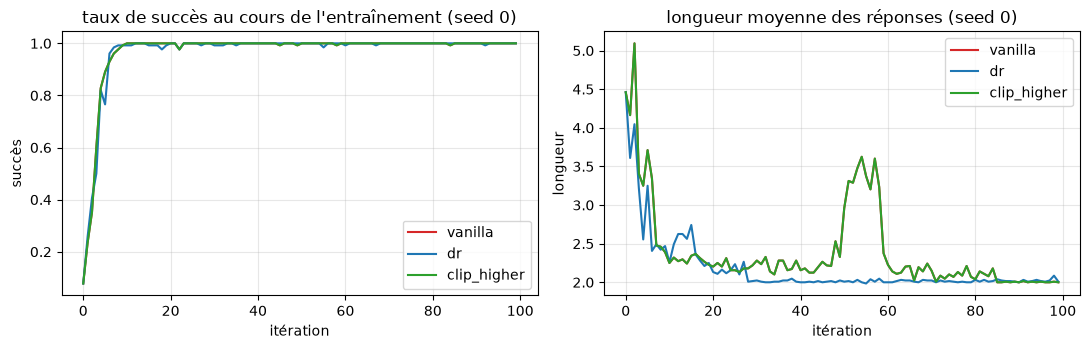

In [13]:
import matplotlib.pyplot as plt
# courbes de succes / longueur pour les 3 variantes (seed 0), une seule collecte par variante
runs = {}
for v in ["vanilla", "dr", "clip_higher"]:
    runs[v] = train(v, 0, collect=True)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for v, col in [("vanilla", "tab:red"), ("dr", "tab:blue"), ("clip_higher", "tab:green")]:
    ax[0].plot(runs[v]["traj"]["succ"], color=col, label=v)
    ax[1].plot(runs[v]["traj"]["len"], color=col, label=v)
ax[0].set_title("taux de succès au cours de l'entraînement (seed 0)")
ax[0].set_xlabel("itération"); ax[0].set_ylabel("succès"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set_title("longueur moyenne des réponses (seed 0)")
ax[1].set_xlabel("itération"); ax[1].set_ylabel("longueur"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig("pt13_training_curves.png", dpi=110, bbox_inches="tight")
plt.show()

**Lecture (les deux panneaux, seed 0).** Chaque panneau trace une seule collecte par variante.
À gauche, le taux de succès au fil des itérations : les trois courbes montent ensemble vers 1 —
il n'y a pas de variante lente ou fautive, la tâche est apprise dans tous les régimes. À droite,
la longueur moyenne des réponses : elle descend vers 2, la longueur de la réponse minimale
`[B_c, S]` — sur ce banc à réponse brève, aucune variante ne développe de verbosité résiduelle
durable. Ce que les courbes ajoutent aux agrégats : le moment où la longueur se fige (tôt), et
l'absence de palier intermédiaire où une politique « gonflerait » ses réponses avant de les
raccourcir. Ce qu'elles **ne peuvent pas** montrer : une discrimination comportementale nette
entre les variantes — la partie 2 (buckets de gradient) porte la démonstration du biais, la
partie 3 vérifie seulement qu'il n'y a pas de contrepartie en performance. Le verdict détaillé
et ses limites suivent dans la cellule d'après.

**Lecture (partie 3, verdict honnête)** — sur ce toy env à réponse brève, les trois variantes
convergent toutes vers la tâche (`succ` ~1) et vers la réponse *minimale* `[B_c,S]` (`len` ~2). Autrement
dit : **les corrections ne coûtent rien** — constat positif. Mais le banc **ne montre pas** de différence
comportementale de longueur ou d'entropie : le couplage entre tokens partagés et la rapidité d'apprentissage
masquent le biais de `1/|o_i|` (c'est la leçon de PT-12 : le banc conditionne ce qui est visible).

**Limite explicite** : une inversion de la consigne en cours d'entraînement fait s'effondrer *les deux*
variantes (symétrique et `clip_higher`) de la même façon — après la bascule, tous les groupes deviennent à
récompense nulle, l'avantage s'annule (groupes à variance nulle), et le modèle gèle. Ce blocage relève du
**dynamic sampling de DAPO** (resampler les groupes constants), **pas** du clip-higher — traité en non-goal
ici. Le clip-higher agit sur la croissance des tokens rares, pas sur la sortie d'un état à avantage nul.

## Interprétation théorique

Les trois corrections de 2025 déplacent GRPO d'un objectif *normalisé* vers un objectif *débiasé* :

| Correction | Ce qu'elle retire | Ce qu'on gagne | Ce qu'on risque |
|---|---|---|---|
| Dr. GRPO `÷|o_i|` → `1/T_MAX` | le bouclier de longueur | pénalité proportionnelle aux tokens émis | un peu plus de variance par sample |
| Dr. GRPO `÷σ` → `r-μ` | l'amplification des groupes uniformes | traitement homogène des difficultés | avantage non unitaire (échelle varie) |
| DAPO clip-higher `ε_high > ε_low` | le gel des tokens rares | exploration maintenue → entropie préservée | un peu plus de bruyance sur les tokens hauts |

Le point de méthode : les trois se **mesurent au niveau du loss** (cisaillement du gradient), pas seulement
au niveau du résultat d'entraînement. C'est ce que ce notebook fait — et là où le toy env ne discrimine
pas, il le **dit**.

## Limites du banc toy (honnêtes)

- MLP à ~2k paramètres, pas un LLM : la mécanique du loss est identique, l'échelle et le régime
  d'exploration ne le sont pas.
- Réponse à 1 bit : la longueur est un choix, pas un besoin (un vrai raisonnement a une longueur
  nécessaire).
- Pas de KL aux refs : les biais théoriques liés à `β·KL` (celui de la question, aussi cité par Dr. GRPO)
  sont hors scope.
- Le verdict MECANISME_REPRO couvre les cellules de mesure (partie 2) ; la partie 3 est un constat
  d'absence de coût + une limite documentée.

## Re-vérification finale avec le vrai vérificateur Z3

On re-vérifie les politiques finales sur des prompts frais par le fast-path, et on compare à la formulation
Z3 (équivalence — thème RLVR).

In [14]:
torch.manual_seed(0); np.random.seed(0)
# politique finale entraînée puis re-vérifiée sur prompts frais (fastpath <-> Z3)
demo = torch.tensor([[1, 3, -1, -1, -1, -1, -1, -1], [2, 3, -1, -1, -1, -1, -1, -1],
                     [0, 0, 1, 3, -1, -1, -1, -1], [0, 0, 2, 3, -1, -1, -1, -1],
                     [0, 1, 3, -1, -1, -1, -1, -1], [0, 2, 3, -1, -1, -1, -1, -1]])
keys = torch.tensor([0, 0, 0, 0, 1, 1])
print("fastpath :", verify_fastpath(demo, keys).astype(int).tolist())
print("z3       :", [1 if ok else 0 for ok in verify_z3_tensor(demo, keys)])
print("(attendu : [1,0,1,0,0,1] — seul le token juste avant STOP doit égaler le bit de la clé)")

# équivalence fastpath <-> Z3 sur un batch de rollouts réels (RLVR : le vérificateur exact fait foi)
torch.manual_seed(1)
mz = PolicyMLP()
kz = torch.tensor([0, 1, 0, 1, 0, 1])
krz, ssz, llz = rollout(mz, kz, 4)
fp = verify_fastpath(ssz, krz)
z3v = verify_z3_tensor(ssz, krz)
print("équivalence fastpath/Z3 sur %d séquences (politique aléatoire) : %s" %
      (len(fp), (fp > 0.5).tolist() == z3v))

fastpath : [1, 0, 1, 0, 0, 1]
z3       : [1, 0, 1, 0, 0, 1]
(attendu : [1,0,1,0,0,1] — seul le token juste avant STOP doit égaler le bit de la clé)
équivalence fastpath/Z3 sur 24 séquences (politique aléatoire) : True


**Lecture (la boucle est bouclée).** Sur 24 séquences générées par une politique aléatoire, la
fastpath et Z3 rendent les mêmes récompenses (`équivalence ... : True`), et la séquence témoin
`[1, 0, 1, 0, 0, 1]` est identique sur les deux chemins. La reward qui a piloté tout
l'entraînement précédent est donc bien celle du vérificateur exact — pas celle d'une imitation
qui aurait divergé de la spécification. L'échantillon couvre des politiques aléatoires (le pire
cas pour couvrir l'espace des séquences), pas une preuve exhaustive ; mais la fastpath est
déterministe et sa spécification tient en une ligne, si bien que l'équivalence observée est
l'assurance raisonnable recherchée. C'est le même geste de clôture qu'en PT-12 : entraîner vite
contre une voie rapide, puis vérifier une dernière fois que la voie rapide disait vrai.

## Exercices

Les trois exercices font travailler les corrigés *sur d'autres points* des trois biais. Stubs `TODO`
(C.1) : le notebook s'exécute de bout en bout même non complété.
Chaque exercice revient sur un point laissé volontairement de côté : le premier réintroduit le
`÷σ` pour *voir* le biais 2 se réinstaller, le deuxième porte la normalisation token-level de
DAPO (la troisième correction du papier, non couverte par les variantes de la partie 1), le
troisième balaye `eps_hi` pour situer la frontière où l'asymétrie de clip cesse d'être sans
effet. Les outils de la partie 2 (buckets, `climb_steps`) servent d'instruments de mesure pour
tous les trois : un corrigé se juge à ses courbes, pas à l'impression d'avoir compris. Conseil de méthode : mesurer avant et après le changement sur au moins trois seeds, et rapporter
les deux tableaux — une différence observée sur un seul seed ne distingue pas un mécanisme d'un
bruit d initialisation.

Un dernier reflexe avant de quitter le notebook : rejouer la cellule de buckets (partie 2.1)
apres chaque exercice — c est le temoin qui dit si la modification demandee a bien deplace le
gradient, et non seulement le resultat affiche.

In [15]:
# TODO etudiant : re-mesurer le biais 2 en reintroduisant /std dans la variante Dr.
# Refaire la table d'amplification de 2.2 avec le /std REINTRODUIT dans dr, et comparer
# la variance cross-seed de succ dans train().
pass  # (a completer - C.1 : le notebook doit tourner meme incomplet)

**Exercice 1 — Réintroduire `/std` dans Dr. GRPO.** Reprendre `make_cfg("dr")`, y reposer
`std_norm=True`, re-entraîner les 5 seeds et comparer la *dispersion* du succès final. Le but est de
vérifier l'affirmation « le `/std` amplifie le bruit des groupes quasi uniformes » : la variance se
creuse-t-elle quand on le réintroduit ?

In [16]:
# TODO etudiant : implémenter le loss token-level de DAPO.
# DAPO normalise par (1 / sum_i |o_i|) sur TOUT le batch (au lieu de 1/G par sample).
# Modifier make_loss pour cette normalisation et comparer convergence.
pass  # (a completer)

**Exercice 2 — Loss token-level (DAPO).** La troisième correction de DAPO normalise par le nombre
*total* de tokens `Σ_i |o_i|` plutôt que par échantillon. L'implémenter dans `make_loss` (nouveau mode
`norm="batch_total"`) et comparer la courbe de succès à `vanilla`. Question : le loss token-level
penalise-t-il davantage les réponses longues (elles pèsent plus dans le dénominateur) ?

In [17]:
# TODO etudiant : balayer eps_high pour trouver le seuil d'echappement.
# Tester eps_high in [0.2, 0.25, 0.28, 0.35, 0.5] sur le toy env, 5 seeds, et tracer
# succ final vs eps_high. Identifier le seuil ou le sur-reglage destabilise.
pass  # (a completer)

**Exercice 3 — Balayer `ε_high`.** Mesurer `succ` final et l'entropie finale pour une grille de
bornes hautes. ATTENTION (table de 2.3) : plus `ε_high` est grand, plus vite les tokens rares remontent,
mais plus l'optimisation peut être bruyante — existe-t-il un optimum intermédiaire sur ce banc ?